# Binary Classification on a Healthcare Dataset
## Comparing Decision Tree, Naive Bayes and K-Nearest Neighbors for Cardiovascular Disease Prediction

**Course:** CSE 3208
**Submitted by:** Md Tayeb Ibne Sayed (Roll: 20230104027, Section A)
**Dataset:** Framingham Heart Study dataset (`framingham.csv`)
**Target variable:** `TenYearCHD` — whether the patient develops coronary heart disease (CHD) within 10 years (1 = yes, 0 = no)

This notebook builds and compares three classifiers — Decision Tree, Naive Bayes, and K-Nearest Neighbors — to predict 10-year cardiovascular (coronary heart disease) risk from routine clinical measurements.

## Section 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

RANDOM_STATE = 42

## Section 3: Load Dataset

The dataset is the **Framingham Heart Study** dataset, a well-known dataset in cardiovascular
risk research. It records demographic, behavioral, and clinical measurements for patients and
whether they developed coronary heart disease (CHD) within the next 10 years.

In [2]:
df = pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Section 4: Initial Dataset Inspection

In [3]:
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

## Section 5: Data Preprocessing

**Missing values:** several clinical columns have missing values (see below). Since the
missing rows are a relatively small fraction of the dataset (about 11.5%) and the dataset
remains well above the required 1,000-sample minimum after removing them, rows with any
missing value are simply dropped. This is the simplest, most transparent approach and avoids
introducing artificial imputed values into a small university assignment.

**Categorical / irrelevant feature:** `education` is an ordinal code (1-4) representing
educational attainment, not a direct physiological measurement. It is dropped because it is
categorical/socioeconomic in nature rather than a clinical risk factor, satisfying the
assignment's requirement to remove categorical features.

In [7]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [8]:
# Drop the categorical/irrelevant feature
df = df.drop(columns=["education"])

# Drop rows with any missing value (done before the split; it only removes
# incomplete records and uses no information from the target)
df = df.dropna().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df["TenYearCHD"].value_counts()

Shape after cleaning: (3751, 15)


TenYearCHD
0    3179
1     572
Name: count, dtype: int64

In [9]:
# Separate features and target
X = df.drop(columns=["TenYearCHD"])
y = df["TenYearCHD"]
X.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


## Section 6: Train/Test Split

The data is split 80/20 with a fixed `random_state` for reproducibility, and stratified on the
target so both sets keep the same ~15%/85% class ratio.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Training set:", X_train.shape, " Testing set:", X_test.shape)

Training set: (3000, 14)  Testing set: (751, 14)


## Section 7: Feature Scaling

KNN classifies points based on distance, so features measured on larger numeric scales (e.g.
`totChol`, `glucose`) would dominate the distance calculation unless every feature is put on a
comparable scale. `StandardScaler` is **fit only on the training data**, then applied to the
test data, to avoid leaking test-set information into preprocessing.

Decision Tree and Naive Bayes do not require scaling (Decision Tree splits on raw thresholds;
GaussianNB models each feature's own distribution), but using the same scaled data for Naive
Bayes does not change its predictions mathematically, so scaled data is used for NB and KNN for
convenience, and raw data for the Decision Tree.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Section 8-10: Model Training

Three classifiers are initialized using Scikit-learn: Decision Tree, Naive Bayes (`GaussianNB`),
and K-Nearest Neighbors. Their key hyperparameters are chosen in Section 11 using cross-validation
on the training data only, then the final models below are trained with those chosen values.

## Section 11: Hyperparameter Experiment (Training Data Only)

A small, understandable experiment is used to choose hyperparameters, using 5-fold
cross-validation **on the training set only** (the test set is never touched during this step).
F1-score is used as the selection metric because the target is imbalanced (~85% negative /
15% positive), so accuracy alone could hide poor performance on the minority (CHD) class.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Decision Tree: max_depth experiment")
best_dt_depth, best_dt_score = None, -1
for depth in [3, 4, 5, 6, 8, 10, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")
    print(f"max_depth={depth}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_dt_score:
        best_dt_score, best_dt_depth = scores.mean(), depth
print("Selected max_depth:", best_dt_depth)

Decision Tree: max_depth experiment
max_depth=3: mean CV F1 = 0.1106
max_depth=4: mean CV F1 = 0.1803


max_depth=5: mean CV F1 = 0.1795


max_depth=6: mean CV F1 = 0.1867
max_depth=8: mean CV F1 = 0.1995


max_depth=10: mean CV F1 = 0.2378


max_depth=None: mean CV F1 = 0.2710
Selected max_depth: None


In [13]:
print("KNN: n_neighbors experiment")
best_k, best_k_score = None, -1
for k in [3, 5, 7, 9, 11, 15, 21]:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring="f1")
    print(f"k={k}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_k_score:
        best_k_score, best_k = scores.mean(), k
print("Selected n_neighbors:", best_k)

KNN: n_neighbors experiment


k=3: mean CV F1 = 0.1875


k=5: mean CV F1 = 0.1652


k=7: mean CV F1 = 0.1572


k=9: mean CV F1 = 0.1203


k=11: mean CV F1 = 0.1115


k=15: mean CV F1 = 0.0864


k=21: mean CV F1 = 0.0650
Selected n_neighbors: 3


In [14]:
print("Naive Bayes: var_smoothing experiment")
best_vs, best_vs_score = None, -1
for vs in [1e-9, 1e-8, 1e-7, 1e-6]:
    clf = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring="f1")
    print(f"var_smoothing={vs}: mean CV F1 = {scores.mean():.4f}")
    if scores.mean() > best_vs_score:
        best_vs_score, best_vs = scores.mean(), vs
print("Selected var_smoothing:", best_vs)

Naive Bayes: var_smoothing experiment
var_smoothing=1e-09: mean CV F1 = 0.2695
var_smoothing=1e-08: mean CV F1 = 0.2695
var_smoothing=1e-07: mean CV F1 = 0.2695
var_smoothing=1e-06: mean CV F1 = 0.2695
Selected var_smoothing: 1e-09


## Section 12: Final Model Training and Test-Set Evaluation

The three models are now trained on the full training set using the hyperparameters selected
above, and evaluated **once** on the held-out test set.

In [15]:
dt_model = DecisionTreeClassifier(max_depth=best_dt_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

nb_model = GaussianNB(var_smoothing=best_vs)
nb_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test)
nb_pred = nb_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)

In [16]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate("Decision Tree", y_test, dt_pred),
    evaluate("Naive Bayes", y_test, nb_pred),
    evaluate("KNN", y_test, knn_pred),
])
results

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.756325,0.206897,0.208696,0.207792
1,Naive Bayes,0.826897,0.380952,0.208696,0.269663
2,KNN,0.817577,0.270833,0.113043,0.159509


## Section 13: Model Comparison

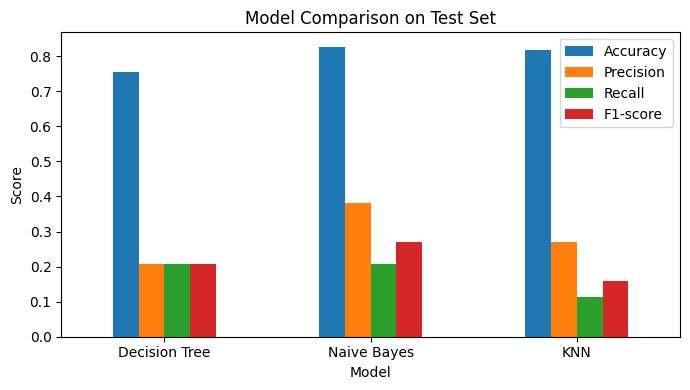

In [17]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(7, 4)
)
plt.ylabel("Score")
plt.title("Model Comparison on Test Set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 14: Additional Visualization

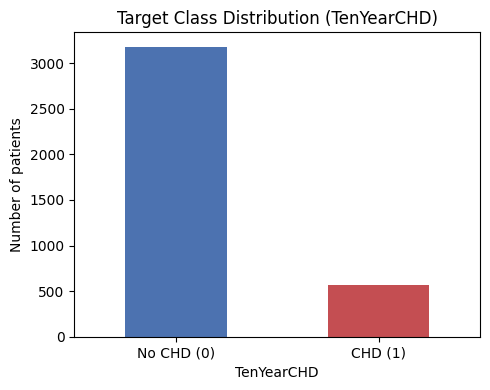

In [18]:
df["TenYearCHD"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(5,4))
plt.xticks([0, 1], ["No CHD (0)", "CHD (1)"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Target Class Distribution (TenYearCHD)")
plt.tight_layout()
plt.show()

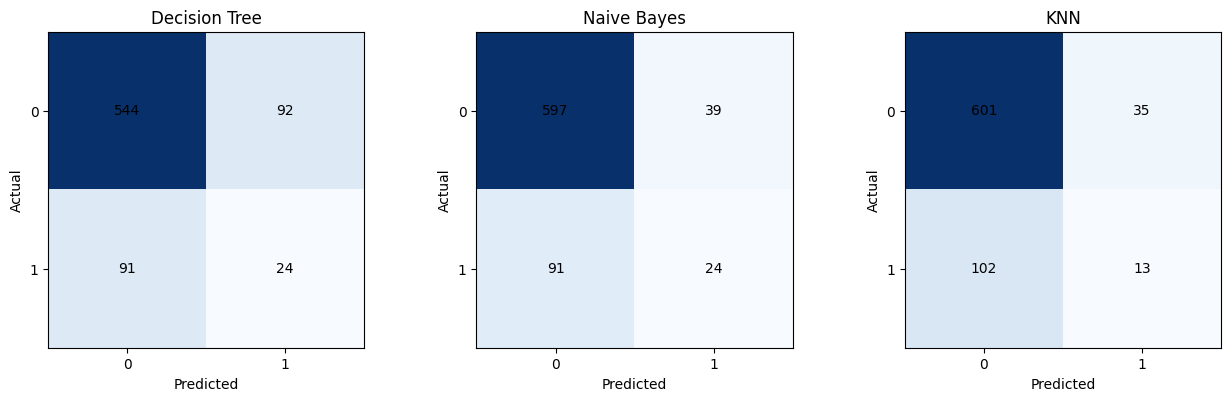

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pred) in zip(
    axes, [("Decision Tree", dt_pred), ("Naive Bayes", nb_pred), ("KNN", knn_pred)]
):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## Section 15: Conclusion

- **Naive Bayes** achieved the best overall test F1-score (0.270) and the highest accuracy
  (82.7%), with the best precision (38.1%) among the three models.
- **Decision Tree** had the lowest accuracy (75.6%) but a comparatively balanced
  precision/recall on the minority class, since an unconstrained tree (chosen by the
  cross-validation experiment) fits the training data closely.
- **KNN** had good accuracy (81.8%) but the lowest recall (11.3%) and F1-score (0.160),
  meaning it misses most actual CHD cases — likely because the CHD class is a small, diffuse
  minority in the scaled feature space, so a distance-based majority vote tends to predict the
  majority (no-CHD) class.
- All three models struggle to reach high recall/F1 on the minority (CHD) class, which is
  expected: only about 15% of patients in the dataset develop CHD within 10 years, and the
  available features are a small subset of the real clinical risk factors used in actual
  cardiovascular risk scoring. This explains why overall accuracy (75-83%) is high while
  F1-scores on the positive class remain modest — the task itself is genuinely hard, not a
  flaw in the code.
- No attempt was made to artificially inflate accuracy (e.g. by rebalancing the test set or
  tuning on the test set); all reported numbers come directly from the single final evaluation
  on the untouched 20% test set.